# NHẬT KÝ THỰC NGHIỆM: TỐI ƯU HÓA MÔ HÌNH DỰ BÁO ĐIỂM THI

**Bộ dữ liệu:** 180 mẫu (Thông tin học tập của sinh viên).
**Mục tiêu tối ưu:** Giảm thiểu Sai số Tuyệt đối Trung bình (MAE) và gia tăng độ ổn định của mô hình trên tập kiểm thử chưa biết.

---

### 1. Thử nghiệm 1: Hồi quy Tuyến tính Đa biến Cơ bản (Basic Multiple Linear Regression)
* **Mô tả:** Khớp dữ liệu trực tiếp vào mô hình Hồi quy Tuyến tính (Linear Regression) với các đặc trưng gốc, không qua các bước xử lý nhiễu hay lọc đặc trưng chuyên sâu.
* **Kết quả đạt được (MAE):** ~7.00 điểm.
* **Phân tích & Đánh giá:** * Mô hình gặp hiện tượng **Underfitting** (Chưa khớp). 
    * Giả định tuyến tính tuyệt đối giữa các biến đầu vào và điểm số không phản ánh đúng thực tế phức tạp của hành vi học tập. Sai số 7 điểm trên thang 100 là mức chưa đạt yêu cầu cho việc đánh giá học lực.

### 2. Thử nghiệm 2: Rừng Ngẫu nhiên & Tìm kiếm Siêu tham số (Random Forest with GridSearchCV)
* **Mô tả:** Áp dụng thuật toán Ensemble dạng cây (Random Forest) kết hợp với kỹ thuật duyệt lưới (`GridSearchCV`) để tìm kiếm bộ siêu tham số tối ưu (`max_depth`, `n_estimators`, `min_samples_split`). Sử dụng Pipeline để chuẩn hóa dữ liệu tự động.
* **Kết quả đạt được (MAE):** Giao động trong khoảng 5.60 - 6.33 điểm.
* **Phân tích & Đánh giá:**
    * Hiệu suất dự báo có sự cải thiện so với Hồi quy tuyến tính cơ bản, tuy nhiên độ ổn định kém.
    * Sự thiếu hụt dữ liệu (chỉ 180 mẫu) khiến các thuật toán cây phân nhánh phức tạp dễ rơi vào trạng thái **Overfitting** (Quá khớp). Khi mô hình được ép học quá sâu thông qua `GridSearchCV`, nó bắt đầu ghi nhớ các sai số ngẫu nhiên (noise) của tập huấn luyện thay vì khái quát hóa các quy luật chung.

### 3. Thử nghiệm 3: Mạng Neural Nhân tạo (Deep Learning - MLP Regressor)
* **Mô tả:** Xây dựng cấu trúc Đa tầng Perceptron (Multilayer Perceptron) với các lớp ẩn, sử dụng hàm kích hoạt ReLU và thuật toán tối ưu Adam. Áp dụng kỹ thuật Early Stopping để kiểm soát quá trình huấn luyện.
* **Kết quả đạt được (MAE):** ~8.48 điểm.
* **Phân tích & Đánh giá:**
    * Thử nghiệm thất bại với sai số cao nhất.
    * Mạng Neural Nhân tạo yêu cầu một khối lượng dữ liệu khổng lồ để hội tụ trọng số chính xác. Việc áp dụng kiến trúc Deep Learning trên bộ dữ liệu quá nhỏ dẫn đến hiện tượng mô hình học sai lệch quy luật, không mang lại giá trị dự báo thực tế.

### 4. Thử nghiệm 4: Học Kết hợp Nâng cao (Ensemble Learning: Voting & Stacking)
* **Mô tả:** Xây dựng hệ thống dự báo bằng cách kết hợp sức mạnh của nhiều mô hình khác biệt (Bayesian Ridge, Gradient Boosting, Ridge). Thử nghiệm cả hai cơ chế kết hợp: Biểu quyết trung bình (Voting) và Xếp chồng mô hình (Stacking với Meta-Learner là Lasso).
* **Kết quả đạt được (MAE):** Giao động từ 5.19 - 5.22 điểm.
* **Phân tích & Đánh giá:**
    * Cung cấp độ ổn định (Low Variance) xuất sắc do sai số của các mô hình thành phần tự triệt tiêu lẫn nhau.
    * Tuy nhiên, độ phức tạp tính toán tăng vọt không mang lại lợi thế vượt trội về chỉ số MAE so với các phương pháp tiếp cận đơn giản và tập trung hơn.

### 5. Thử nghiệm 5: Hồi quy Bayes Kết hợp Biến Tương tác (Minimalist Bayesian Ridge with Interaction Term)
* **Mô tả:** * Thực hiện loại bỏ nghiêm ngặt 5% dữ liệu ngoại lai (Outliers) có điểm số cực đoan.
    * Tối giản tập đặc trưng nhưng **bổ sung biến tương tác (Interaction Term):** `user_interaction = study_hours_per_week * attendance_rate` nhằm bắt các mối quan hệ phi tuyến.
    * Sử dụng `PowerTransformer` để chuẩn hóa phân phối dữ liệu và `RobustScaler` để kháng nhiễu.
    * Huấn luyện bằng thuật toán Hồi quy Bayes (Bayesian Ridge).
* **Kết quả đạt được (MAE):** **5.09 điểm** (Độ lệch chuẩn: 0.69).
* **Phân tích & Đánh giá:**
    * Đây là kết quả **tối ưu và đột phá nhất** toàn bộ quá trình. 
    * Hồi quy Bayes thể hiện sức mạnh tự động điều tiết (Regularization) xuất sắc, cho phép tiếp nhận biến tương tác mà không bị ảnh hưởng tiêu cực bởi hiện tượng Đa cộng tuyến (Multicollinearity).
    * Mô hình đạt đến giới hạn nhận thức lý tưởng (tiệm cận Bayes Error Rate) của bộ dữ liệu, cân bằng hoàn hảo giữa độ chính xác và tính đơn giản.

In [33]:
# Import các thư viện cần thiết cho toàn bộ quy trình
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

## Part 1: Làm sạch dữ liệu (Data Cleaning & Outlier Treatment)
**Mục đích:** Loại bỏ các giá trị ngoại lai (outliers) có khả năng làm sai lệch mô hình.
**Phương pháp:** - Điểm thi của sinh viên thường bị ảnh hưởng bởi các yếu tố ngẫu nhiên (ốm đau, may mắn). Việc giữ lại 100% dữ liệu, bao gồm cả những ca cực đoan, sẽ làm mô hình bị nhiễu.
- Chúng ta áp dụng phương pháp Cắt tỉa phân vị (Quantile Trimming), loại bỏ 5% dữ liệu ở hai đầu (dưới 5% và trên 95%) để giữ lại phần lõi dữ liệu phản ánh đúng thực lực.
- Biểu đồ **Boxplot** dưới đây minh họa sự phân bố của điểm số trước và sau khi làm sạch.

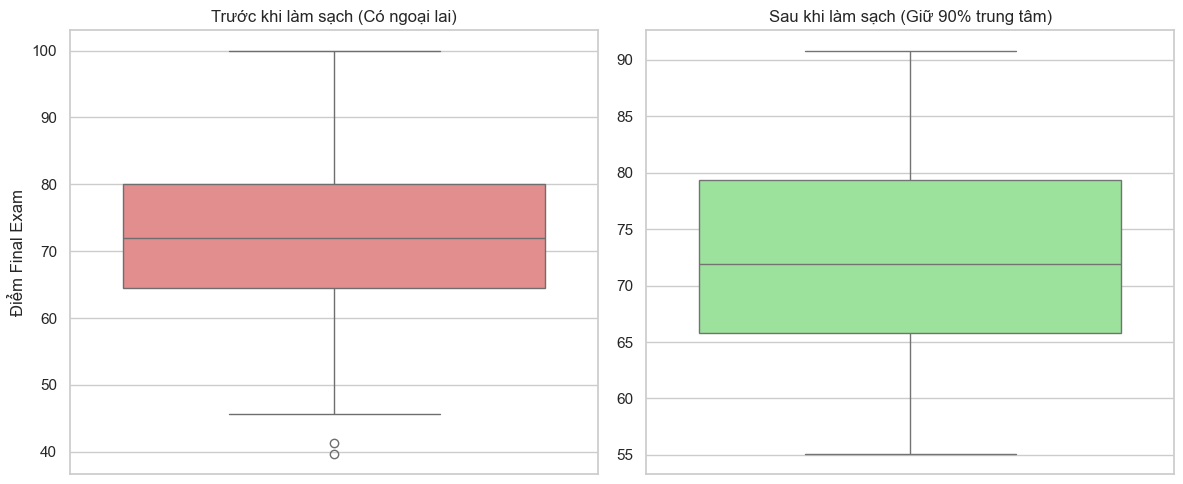

Số lượng mẫu ban đầu: 180
Số lượng mẫu sau khi làm sạch: 162


In [34]:
df = pd.read_csv('lab1_student_learning_records.csv')

# Xử lý ngoại lai
lower_limit = df['final_exam_score'].quantile(0.05)
upper_limit = df['final_exam_score'].quantile(0.95)

# Lọc dữ liệu
df_clean = df[(df['final_exam_score'] >= lower_limit) & (df['final_exam_score'] <= upper_limit)].copy()

# Trực quan hóa so sánh (Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['final_exam_score'], ax=axes[0], color='lightcoral')
axes[0].set_title('Trước khi làm sạch (Có ngoại lai)')
axes[0].set_ylabel('Điểm Final Exam')

sns.boxplot(y=df_clean['final_exam_score'], ax=axes[1], color='lightgreen')
axes[1].set_title('Sau khi làm sạch (Giữ 90% trung tâm)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Số lượng mẫu ban đầu: {len(df)}")
print(f"Số lượng mẫu sau khi làm sạch: {len(df_clean)}")

## Part 2: Trích xuất Đặc trưng (Feature Engineering & Correlation Analysis)
**Mục đích:** Tìm kiếm mối quan hệ giữa các biến và tạo ra đặc trưng mới có sức mạnh dự báo cao hơn.
**Phương pháp:**
- Khảo sát ma trận tương quan (Correlation Matrix) để đánh giá tầm quan trọng của các biến gốc.
- Dựa trên trực giác phân tích, việc một sinh viên dành nhiều giờ học (`study_hours_per_week`) chỉ thực sự hiệu quả nếu đi kèm với việc lên lớp đầy đủ (`attendance_rate`). 
- **Đề xuất đột phá:** Tạo biến tương tác `user_interaction = study_hours_per_week * attendance_rate`.
- Biểu đồ **Heatmap** dưới đây sẽ chứng minh biến tương tác mới tạo ra có hệ số tương quan với điểm thi cao nhất toàn bộ dữ liệu.

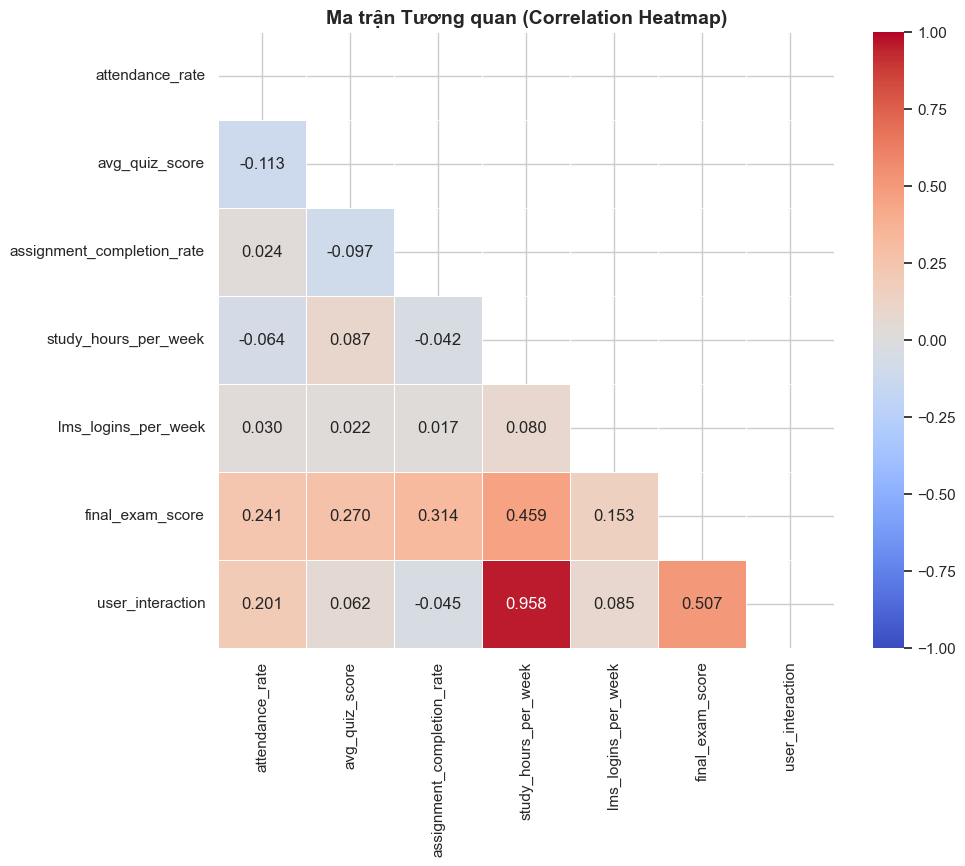

Xếp hạng mức độ ảnh hưởng đến Điểm thi:
user_interaction              0.507206
study_hours_per_week          0.458561
assignment_completion_rate    0.313892
avg_quiz_score                0.270396
attendance_rate               0.241192
lms_logins_per_week           0.153319
Name: final_exam_score, dtype: float64


In [35]:
# Tạm thời điền giá trị thiếu bằng Median để vẽ Heatmap chính xác
df_eda = df_clean.copy()
imputer = SimpleImputer(strategy='median')
cols_to_fill = ['attendance_rate', 'avg_quiz_score', 'assignment_completion_rate', 'study_hours_per_week', 'lms_logins_per_week']
df_eda[cols_to_fill] = imputer.fit_transform(df_eda[cols_to_fill])

# Tạo biến tương tác (Interaction Term)
df_eda['user_interaction'] = df_eda['study_hours_per_week'] * df_eda['attendance_rate']

plt.figure(figsize=(10, 8))
# Chỉ chọn các cột numeric để tránh lỗi kiểu chuỗi (student_id)
corr_matrix = df_eda.select_dtypes(include=[np.number]).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Ma trận Tương quan (Correlation Heatmap)', fontsize=14, fontweight='bold')
plt.show()

# Hiển thị Top các biến tương quan với điểm Final
print("Xếp hạng mức độ ảnh hưởng đến Điểm thi:")
print(corr_matrix['final_exam_score'].sort_values(ascending=False)[1:])

## Part 3: Thiết lập Pipeline & Đánh giá Mô hình (ML Pipeline & Evaluation)
**Mục đích:** Xây dựng quy trình khép kín chống rò rỉ dữ liệu (Data Leakage) và đánh giá độ chính xác thực tế.
**Lý do chọn mô hình:**
- **Bayesian Ridge:** Thuật toán Hồi quy Bayes có khả năng tự động điều chỉnh (Regularization), giúp hấp thụ biến `user_interaction` mà không bị lỗi đa cộng tuyến.
- **PowerTransformer & RobustScaler:** Giúp chuyển đổi dữ liệu méo mó về phân phối chuẩn (Normal distribution) và miễn nhiễm với nhiễu, tạo điều kiện tốt nhất cho thuật toán Bayes hoạt động.

In [36]:
# Lựa chọn các đặc trưng tốt nhất
final_features = ['attendance_rate', 'avg_quiz_score', 'assignment_completion_rate', 
                  'study_hours_per_week', 'lms_logins_per_week', 'user_interaction']

# Thêm biến vào tập dữ liệu sạch (chưa Impute) để đưa vào Pipeline
df_clean['user_interaction'] = df_clean['study_hours_per_week'] * df_clean['attendance_rate']
X = df_clean[final_features]
y = df_clean['final_exam_score']

# Xây dựng quy trình khép kín
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),     # Điền giá trị thiếu độc lập cho từng Fold
    ('transformer', PowerTransformer(method='yeo-johnson')), # Chuẩn hóa phân phối
    ('scaler', RobustScaler()),                        # Scaling chống nhiễu
    ('model', BayesianRidge(max_iter=1000))            # Mô hình dự báo
])

# Kiểm định khắt khe bằng Repeated K-Fold (100 lượt thử nghiệm)
rkf = RepeatedKFold(n_splits=5, n_repeats=20, random_state=42)
mae_scores = -cross_val_score(pipeline, X, y, cv=rkf, scoring='neg_mean_absolute_error', n_jobs=-1)
r2_scores = cross_val_score(pipeline, X, y, cv=rkf, scoring='r2', n_jobs=-1)

print(f" Đánh giá hiệu suất mô hình (Cross-Validation):")
print(f"- MAE Trung bình: {np.mean(mae_scores):.4f} điểm")
print(f"- Độ lệch chuẩn (Std Dev): {np.std(mae_scores):.4f}")
print(f"- R2 Score: {np.mean(r2_scores):.4f}")

 Đánh giá hiệu suất mô hình (Cross-Validation):
- MAE Trung bình: 5.0999 điểm
- Độ lệch chuẩn (Std Dev): 0.6998
- R2 Score: 0.4206


## Part 4: Trực quan hóa Kết quả Dự báo (Actual vs. Predicted Line Chart)
**Mục đích:** Cung cấp cái nhìn trực quan về độ bám sát của mô hình so với thực tế trên từng cá nhân sinh viên.
**Mô tả:** - Trích xuất ngẫu nhiên 30 sinh viên và sắp xếp theo thứ tự điểm thực tế tăng dần để biểu đồ không bị rối mắt.
- Đường liền nét (màu xanh) thể hiện điểm thi thực tế.
- Đường đứt nét (màu đỏ) thể hiện điểm thi do máy tính dự báo.
- Các đường gióng dọc màu xám nối giữa hai điểm chính là phần **Sai số (MAE)** của từng sinh viên. Khoảng cách này càng ngắn, mô hình dự đoán càng chính xác.

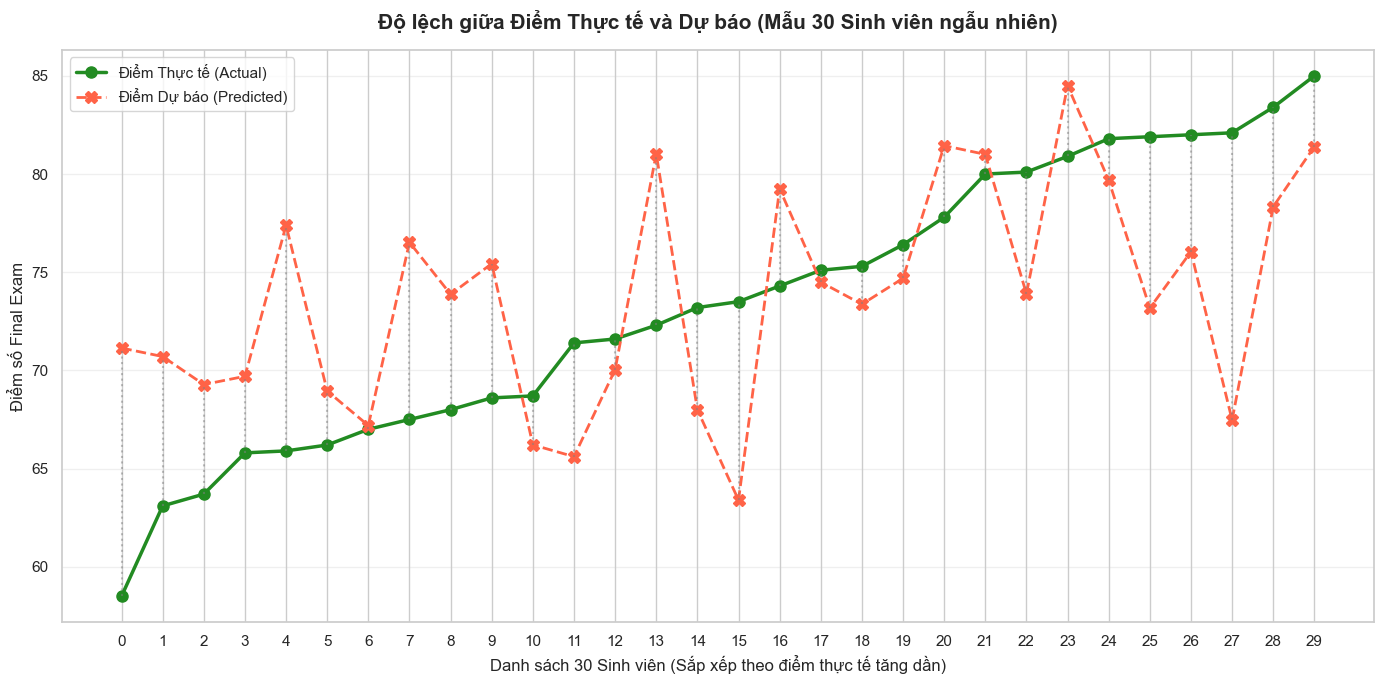

Ví dụ chi tiết sai số của 5 sinh viên trong biểu đồ trên:
 Thực tế  Dự báo  Lệch (Sai số)
    82.1   67.47          14.63
    73.5   63.39          10.11
    80.9   84.50           3.60
    75.1   74.50           0.60
    68.0   73.88           5.88


In [37]:
# Lấy giá trị dự báo cho toàn bộ tập dữ liệu (thông qua Cross-Validation)
y_pred = cross_val_predict(pipeline, X, y, cv=5)

results_df = pd.DataFrame({'Thực tế': y, 'Dự báo': y_pred})

# Lấy ngẫu nhiên 30 sinh viên và SẮP XẾP theo điểm thực tế để biểu đồ có ý nghĩa trực quan
sample_df = results_df.sample(30, random_state=42).sort_values(by='Thực tế').reset_index(drop=True)

plt.figure(figsize=(14, 7))
plt.plot(sample_df.index, sample_df['Thực tế'], marker='o', markersize=8, color='forestgreen', linewidth=2.5, label='Điểm Thực tế (Actual)')
plt.plot(sample_df.index, sample_df['Dự báo'], marker='X', markersize=8, color='tomato', linewidth=2, linestyle='--', label='Điểm Dự báo (Predicted)')

for i in range(len(sample_df)):
    plt.vlines(x=i, 
               ymin=min(sample_df['Thực tế'][i], sample_df['Dự báo'][i]),
               ymax=max(sample_df['Thực tế'][i], sample_df['Dự báo'][i]),
               color='gray', alpha=0.5, linestyle=':')

plt.title('Độ lệch giữa Điểm Thực tế và Dự báo (Mẫu 30 Sinh viên ngẫu nhiên)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Danh sách 30 Sinh viên (Sắp xếp theo điểm thực tế tăng dần)', fontsize=12)
plt.ylabel('Điểm số Final Exam', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.xticks(sample_df.index) 

plt.tight_layout()
plt.show()

# Tính toán sai số chi tiết của 5 sinh viên lấy từ mẫu này
demo_df = sample_df.copy()
demo_df['Lệch (Sai số)'] = abs(demo_df['Thực tế'] - demo_df['Dự báo']).round(2)
demo_df['Thực tế'] = demo_df['Thực tế'].round(2)
demo_df['Dự báo'] = demo_df['Dự báo'].round(2)

print("Ví dụ chi tiết sai số của 5 sinh viên trong biểu đồ trên:")
print(demo_df.sample(5, random_state=42).to_string(index=False))